# Stage 4 — On-the-fly PyTorch Dataset (Zero Disk Space)

Instead of saving patches to disk, the Dataset reads 512×512 windows **directly from the original TIF files** during training.

**How it works:**
1. At startup: scan each TIF at overview scale → find positions that contain canal lines
2. During training: randomly pick a position → read full-res 512×512 patch → compute 5-class mask → return to model
3. Zero extra disk space needed

**Split:**
| Set | Files |
|---|---|
| Train | ATTANUR_1, ATTANUR_4, SHAKAPUR |
| Val | ATTANUR_3 |
| Test | ATTANUR_2 |

In [15]:
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import rasterio
from rasterio.windows import Window
import cv2
from skimage.morphology import skeletonize
from skimage.measure import label, regionprops
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import random
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

DATA_DIR   = r'c:/Users/PRABHAKAR/Documents/Wells-Lab'
PATCH_SIZE = 512
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'

TRAIN_FILES = {
    'ATTANUR_1': (os.path.join(DATA_DIR,'TLBC_D95_ATTANUR_1_ortho.tif'), 0.0462),
    'ATTANUR_4': (os.path.join(DATA_DIR,'TLBC_D95_ATTANUR_4_ortho.tif'), 0.0352),
    'SHAKAPUR':  (os.path.join(DATA_DIR,'TLBC_D95_SHAKAPUR_ortho.tif'),  0.0342),
}
VAL_FILES = {
    'ATTANUR_3': (os.path.join(DATA_DIR,'TLBC_D95_ATTANUR_3_ortho.tif'), 0.0462),
}
TEST_FILES = {
    'ATTANUR_2': (os.path.join(DATA_DIR,'TLBC_D95_ATTANUR_2_ortho.tif'), 0.0462),
}

print(f'Device: {DEVICE}')
print('Files configured')

Device: cuda
Files configured


In [ ]:
# ── Mask builder v4 — corrected thresholds from irrigation standards ──────────
#
# Real canal hierarchy (TLBC D-95, Raichur):
#   Main/Branch : concrete, 12-45 m wide, bright grey, uniform, very long
#   Distributary: concrete/mixed, 3-12 m, grey/brown stripe, branches at angles
#   Minor       : mostly earthen, 1.5-4 m, thin brown line
#   FIC         : earthen, 0.3-1.0 m, very thin, grassy/brown, connects to minor
#   Field bund  : earthen, 0.1-0.3 m, forms CLOSED RECTANGLES around fields

def vari(r, g, b):
    d = g.astype(float) + r.astype(float) - b.astype(float)
    d = np.where(np.abs(d) < 1e-6, 1e-6, d)
    return np.clip((g.astype(float) - r.astype(float)) / d, -1, 1)

def linearity_filter(mask, min_aspect=2.5, max_blob_area=None):
    labeled  = label(mask, connectivity=2)
    filtered = np.zeros_like(mask, dtype=bool)
    for region in regionprops(labeled):
        if region.area < 8: continue
        minor  = region.minor_axis_length
        aspect = (region.major_axis_length / minor) if minor > 1e-3 else region.major_axis_length
        if aspect >= min_aspect or (max_blob_area and region.area <= max_blob_area):
            filtered[labeled == region.label] = True
    return filtered

def make_mask(r, g, b, valid, px_m):
    """Returns uint8 mask: 0=bg 1=main/branch 2=distrib 3=minor 4=FIC 5=bund"""
    bright = (r + g + b) / 3.0
    grey   = np.abs(r-g) + np.abs(g-b)
    vi     = vari(r, g, b)

    main_min_w    = int(12.0 / px_m)
    distrib_min_w = int(3.0  / px_m)
    minor_min_w   = int(1.5  / px_m)
    fic_min_w     = max(2, int(0.3 / px_m))
    fic_max_w     = int(1.0  / px_m)
    conn_px       = max(5, int(3.5 / px_m))
    min_skel_len  = max(10, int(5.0 / px_m))
    min_canal_area= max(50, int(1.0 / (px_m**2)))

    k3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
    k5 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))

    c_raw = (valid & (vi < 0.06) & (bright > 120) & (grey < 25)).astype(np.uint8)
    c_raw = cv2.morphologyEx(c_raw, cv2.MORPH_OPEN,  k3)
    c_raw = cv2.morphologyEx(c_raw, cv2.MORPH_CLOSE, k5)
    c_dist = cv2.distanceTransform(c_raw * 255, cv2.DIST_L2, 5) * 2
    c_bool = c_raw.astype(bool)
    c_skel = skeletonize(c_bool)

    out = np.zeros(r.shape, dtype=np.uint8)
    concrete = np.zeros(r.shape, dtype=bool)
    c_lab = label(c_bool, connectivity=2)

    for region in regionprops(c_lab):
        comp = c_lab == region.label
        if region.area < min_canal_area: continue
        minor_ax = region.minor_axis_length
        aspect = (region.major_axis_length / minor_ax) if minor_ax > 1e-3 else region.major_axis_length
        if aspect < 4.0: continue
        sp = comp & c_skel
        if sp.sum() < min_skel_len: continue
        widths = c_dist[sp]; widths = widths[widths > 0]
        if widths.size == 0: continue
        med_w = float(np.median(widths))
        cv_w  = float(np.std(widths)) / (med_w + 1e-6)
        if cv_w > 0.5: continue
        concrete[comp] = True
        if   med_w >= main_min_w:    out[comp] = 1
        elif med_w >= distrib_min_w: out[comp] = 2
        elif med_w >= minor_min_w:   out[comp] = 3
        else:                        out[comp] = 3

    water_hint = (valid & (bright < 60) & (grey < 20) & ~concrete).astype(np.uint8)
    earthen = (valid & (vi < 0.09) & (bright > 65) & (bright < 215)
               & (r > b + 3) & (grey >= 10) & ~concrete)
    grassy_raw = (valid & (vi > 0.10) & (vi < 0.60)
                  & (bright > 30) & (bright < 210) & ~concrete).astype(np.uint8)
    grassy_raw = cv2.morphologyEx(grassy_raw, cv2.MORPH_OPEN, k3)
    grassy_dist = cv2.distanceTransform(grassy_raw, cv2.DIST_L2, 5)
    grassy_narrow = grassy_raw.astype(bool) & (grassy_dist <= fic_max_w * 0.75)

    e_raw = (grassy_narrow | earthen).astype(np.uint8)
    e_raw = cv2.morphologyEx(e_raw, cv2.MORPH_OPEN,  k3)
    e_raw = cv2.morphologyEx(e_raw, cv2.MORPH_CLOSE, k3)

    e_labeled = label(e_raw.astype(bool), connectivity=2)
    candidates = np.zeros(r.shape, dtype=bool)
    for region in regionprops(e_labeled):
        if region.area < 30: continue
        minor_ax = region.minor_axis_length
        aspect = (region.major_axis_length / minor_ax) if minor_ax > 1e-3 else region.major_axis_length
        if aspect >= 3.0: candidates[e_labeled == region.label] = True

    e_dist = cv2.distanceTransform(candidates.astype(np.uint8)*255, cv2.DIST_L2, 5) * 2
    e_skel = skeletonize(candidates)
    ck    = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (conn_px*2+1, conn_px*2+1))
    c_dil = cv2.dilate(concrete.astype(np.uint8), ck).astype(bool)
    wk_size = max(3, fic_max_w // 2 * 2 + 1)
    wk = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (wk_size, wk_size))

    e_lab = label(candidates, connectivity=2)
    for region in regionprops(e_lab):
        comp = e_lab == region.label
        sp   = comp & e_skel
        if not sp.any(): out[comp] = 5; continue
        if sp.sum() < max(5, int(2.0 / px_m)): out[comp] = 5; continue
        med = float(np.median(e_dist[sp]))
        e_widths = e_dist[sp]; e_widths = e_widths[e_widths > 0]
        if e_widths.size > 0:
            e_cv = float(np.std(e_widths)) / (float(np.mean(e_widths)) + 1e-6)
            if e_cv > 0.6: out[comp] = 5; continue
        touches_concrete = bool((comp & c_dil).any())
        comp_expanded    = cv2.dilate(comp.astype(np.uint8), wk).astype(bool)
        has_water        = bool((comp_expanded & water_hint.astype(bool)).any())
        if minor_min_w <= med <= distrib_min_w and touches_concrete:
            out[comp] = 3
        elif fic_min_w <= med <= fic_max_w and (touches_concrete or has_water):
            out[comp] = 4
        else:
            out[comp] = 5

    out[~valid] = 0
    return out

print('Mask builder v4 ready (corrected from irrigation standards)')

In [17]:
# ── Canal-aware position scanner ──────────────────────────────────────────────
# Scans each file at overview scale, returns full-res positions
# likely to contain canal lines.

def scan_positions(fpath, patch_size=PATCH_SIZE, overview_px=800, min_canal_score=0.01):
    """
    Returns list of (col, row) full-res positions where canal-like
    features are likely present.
    """
    with rasterio.open(fpath) as src:
        W, H  = src.width, src.height
        scale = max(1, max(W,H) // overview_px)
        ow, oh = W//scale, H//scale
        data  = src.read([1,2,3], out_shape=(3, oh, ow)).astype(np.float32)

    r, g, b = data[0], data[1], data[2]
    valid   = (r + g + b) >= 15
    vi      = vari(r, g, b)
    bright  = (r + g + b) / 3.0

    canal_hint = (valid & (vi < 0.07) & (bright > 80)).astype(np.uint8)

    # emphasise linear features
    linear = np.zeros_like(canal_hint)
    for angle in [0, 90, 45, 135]:
        length = max(3, 12)
        kern   = np.zeros((3, length), np.uint8); kern[1,:] = 1
        M      = cv2.getRotationMatrix2D((length//2, 1), angle, 1)
        kern   = cv2.warpAffine(kern, M, (length, 3)).astype(np.uint8)
        if kern.sum() > 0:
            linear = np.maximum(linear, cv2.morphologyEx(canal_hint, cv2.MORPH_OPEN, kern))

    # slide window at overview scale
    pw   = max(4, patch_size // scale)
    step = max(2, pw // 2)
    positions = []
    for ry in range(0, oh - pw + 1, step):
        for cx in range(0, ow - pw + 1, step):
            vw = valid[ry:ry+pw, cx:cx+pw]
            if vw.sum() < pw*pw*0.35: continue
            score = linear[ry:ry+pw, cx:cx+pw].sum() / max(1, vw.sum())
            if score >= min_canal_score:
                co = min(cx*scale, W - patch_size)
                ro = min(ry*scale, H - patch_size)
                positions.append((int(co), int(ro)))

    print(f'  {os.path.basename(fpath)}: {len(positions)} candidate positions '
          f'(scale 1:{scale}  overview {ow}x{oh})')
    return positions, W, H

print('Position scanner ready')

Position scanner ready


In [18]:
# ── CanalDataset ──────────────────────────────────────────────────────────────

class CanalDataset(Dataset):
    """
    On-the-fly dataset. Reads 512x512 patches directly from TIF files.
    No patches saved to disk.

    Args:
        files       : dict {TAG: (fpath, px_m)}
        augment     : apply random flips + rotations (train only)
        epoch_size  : number of patches per epoch
        jitter_px   : random position jitter in pixels (train only)
    """

    def __init__(self, files, augment=False, epoch_size=1000, jitter_px=128):
        self.files      = files
        self.augment    = augment
        self.epoch_size = epoch_size
        self.jitter_px  = jitter_px

        # Scan positions for each file
        print('Scanning positions ...')
        self.file_positions = {}   # TAG -> list of (col, row)
        self.file_dims      = {}   # TAG -> (W, H)
        self.weights        = []   # sampling weight per file
        self.tags           = []

        for tag, (fpath, px_m) in files.items():
            positions, W, H = scan_positions(fpath)
            self.file_positions[tag] = positions
            self.file_dims[tag]      = (W, H)
            self.tags.append(tag)
            self.weights.append(len(positions))

        total = sum(self.weights)
        self.weights = [w/total for w in self.weights]
        print(f'Ready. Total candidate positions: {total:,}')

    def __len__(self):
        return self.epoch_size

    def __getitem__(self, idx):
        # pick a file weighted by number of canal positions
        tag = random.choices(self.tags, weights=self.weights, k=1)[0]
        fpath, px_m = self.files[tag]
        W, H = self.file_dims[tag]

        # pick a random position from that file
        base_col, base_row = random.choice(self.file_positions[tag])

        # add jitter (train only)
        if self.augment and self.jitter_px > 0:
            base_col += random.randint(-self.jitter_px, self.jitter_px)
            base_row += random.randint(-self.jitter_px, self.jitter_px)

        col_off = int(np.clip(base_col, 0, W - PATCH_SIZE))
        row_off = int(np.clip(base_row, 0, H - PATCH_SIZE))

        # read patch
        with rasterio.open(fpath) as src:
            data = src.read([1,2,3],
                            window=Window(col_off, row_off, PATCH_SIZE, PATCH_SIZE)
                            ).astype(np.float32)

        r, g, b = data[0], data[1], data[2]
        valid   = (r + g + b) >= 15

        # compute 5-class mask
        mask = make_mask(r, g, b, valid, px_m)

        # normalise image to [0,1]
        img = np.stack([r, g, b], axis=0).clip(0, 255) / 255.0
        img_t  = torch.from_numpy(img).float()           # (3, H, W)
        mask_t = torch.from_numpy(mask).long()           # (H, W)  values 0-5

        # augmentation (train only)
        if self.augment:
            # random horizontal flip
            if random.random() > 0.5:
                img_t  = TF.hflip(img_t)
                mask_t = TF.hflip(mask_t.unsqueeze(0)).squeeze(0)
            # random vertical flip
            if random.random() > 0.5:
                img_t  = TF.vflip(img_t)
                mask_t = TF.vflip(mask_t.unsqueeze(0)).squeeze(0)
            # random 90° rotation
            k = random.choice([0,1,2,3])
            if k > 0:
                img_t  = torch.rot90(img_t,  k, dims=[1,2])
                mask_t = torch.rot90(mask_t, k, dims=[0,1])

        return img_t, mask_t

print('CanalDataset class defined')

CanalDataset class defined


In [19]:
# ── Build datasets and dataloaders ────────────────────────────────────────────

print('Building train dataset ...')
train_ds = CanalDataset(TRAIN_FILES, augment=True,  epoch_size=1000)

print('\nBuilding val dataset ...')
val_ds   = CanalDataset(VAL_FILES,   augment=False, epoch_size=200)

print('\nBuilding test dataset ...')
test_ds  = CanalDataset(TEST_FILES,  augment=False, epoch_size=200)

train_loader = DataLoader(train_ds, batch_size=8,  shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=8,  shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=8,  shuffle=False, num_workers=0, pin_memory=True)

print(f'\nTrain batches/epoch : {len(train_loader)}')
print(f'Val   batches/epoch : {len(val_loader)}')
print(f'Test  batches       : {len(test_loader)}')

Building train dataset ...
Scanning positions ...
  TLBC_D95_ATTANUR_1_ortho.tif: 18986 candidate positions (scale 1:64  overview 506x812)
  TLBC_D95_ATTANUR_4_ortho.tif: 9943 candidate positions (scale 1:54  overview 327x810)
  TLBC_D95_SHAKAPUR_ortho.tif: 50212 candidate positions (scale 1:110  overview 804x380)
Ready. Total candidate positions: 79,141

Building val dataset ...
Scanning positions ...
  TLBC_D95_ATTANUR_3_ortho.tif: 50170 candidate positions (scale 1:173  overview 363x803)
Ready. Total candidate positions: 50,170

Building test dataset ...
Scanning positions ...
  TLBC_D95_ATTANUR_2_ortho.tif: 62711 candidate positions (scale 1:171  overview 466x804)
Ready. Total candidate positions: 62,711

Train batches/epoch : 125
Val   batches/epoch : 25
Test  batches       : 25


Batch shape  — images: torch.Size([8, 3, 512, 512])  masks: torch.Size([8, 512, 512])
Image range  — min: 0.000  max: 1.000
Mask classes — unique: [0, 3, 4, 5]


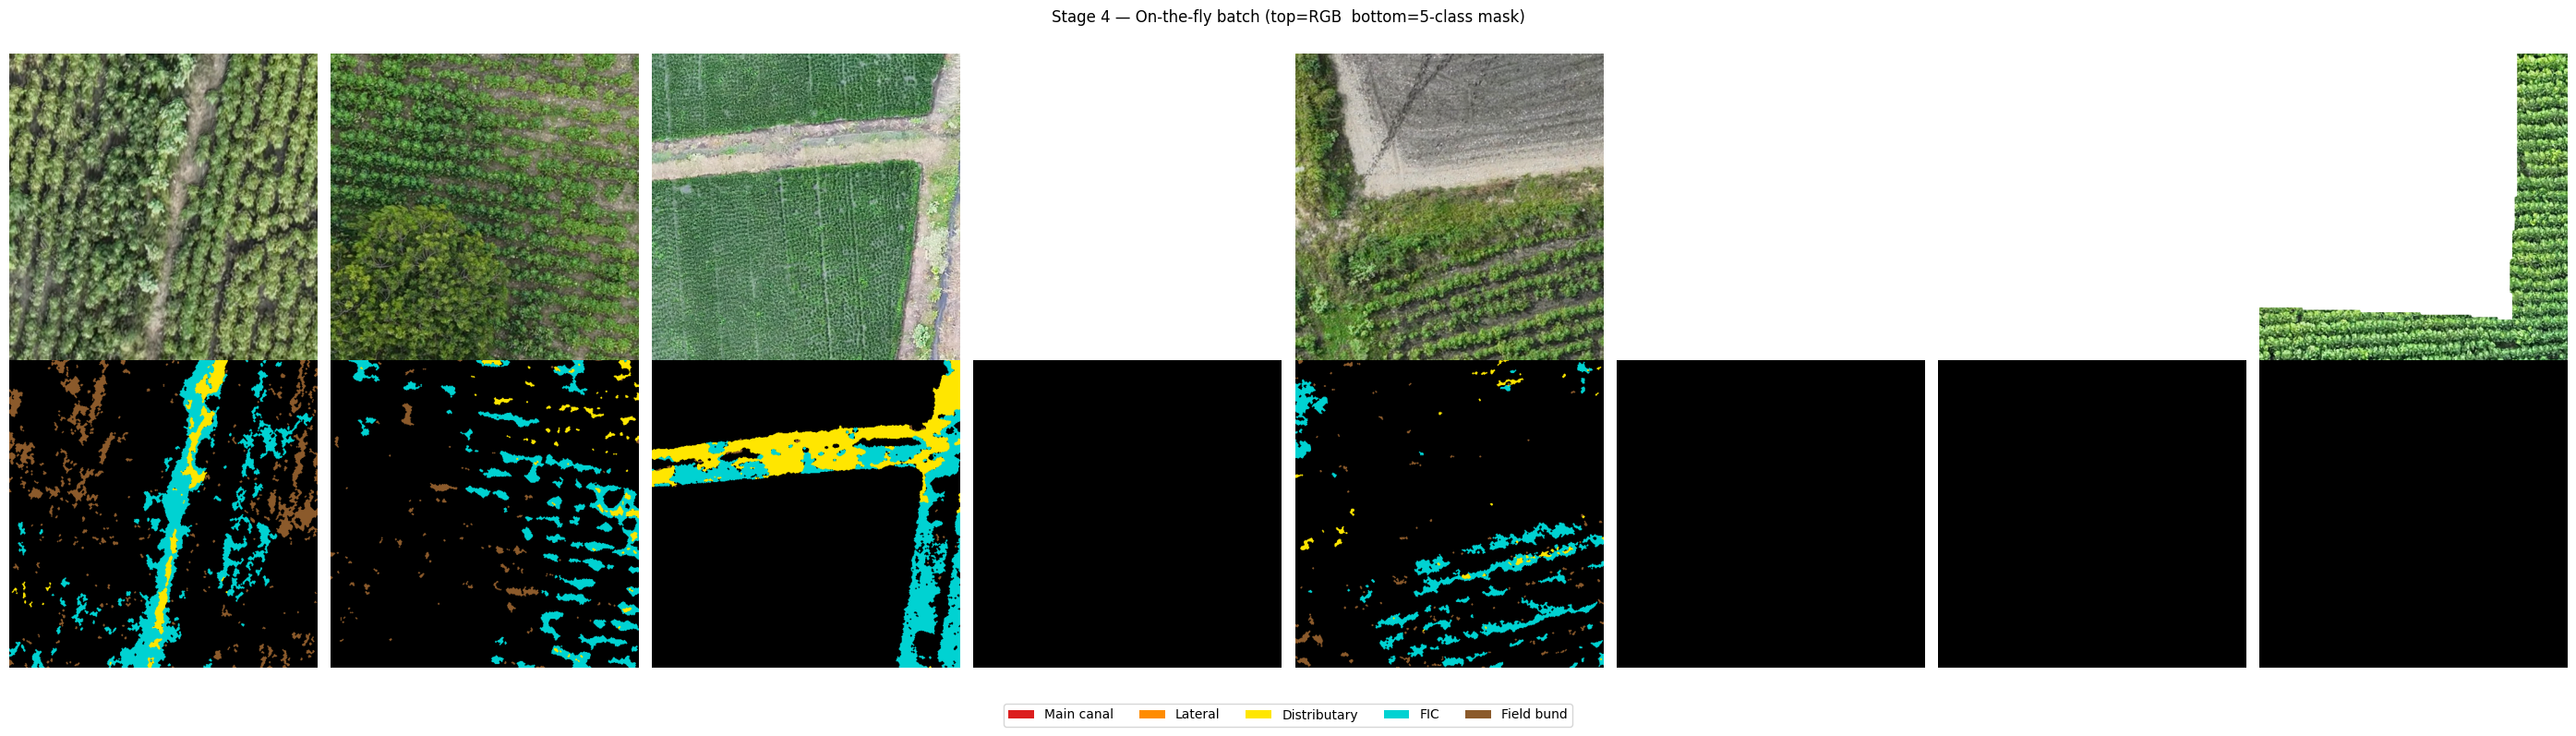

Batch visualisation saved.


In [20]:
# ── Sanity check — visualise one batch ───────────────────────────────────────

CLS_COL = {
    0:[0,0,0],     1:[220,30,30],  2:[255,140,0],
    3:[255,230,0], 4:[0,210,210],  5:[139,90,43]
}

def mask_to_rgb(mask_np):
    out = np.zeros((*mask_np.shape,3), dtype=np.uint8)
    for c, col in CLS_COL.items(): out[mask_np==c] = col
    return out

imgs, masks = next(iter(train_loader))
print(f'Batch shape  — images: {imgs.shape}  masks: {masks.shape}')
print(f'Image range  — min: {imgs.min():.3f}  max: {imgs.max():.3f}')
print(f'Mask classes — unique: {masks.unique().tolist()}')

fig, axes = plt.subplots(2, 8, figsize=(28, 8))
fig.suptitle('Stage 4 — On-the-fly batch (top=RGB  bottom=5-class mask)', fontsize=12)
for i in range(min(8, imgs.shape[0])):
    img_np  = (imgs[i].permute(1,2,0).numpy() * 255).astype(np.uint8)
    mask_np = masks[i].numpy().astype(np.uint8)
    axes[0,i].imshow(img_np);           axes[0,i].axis('off')
    axes[1,i].imshow(mask_to_rgb(mask_np)); axes[1,i].axis('off')

fig.legend(handles=[
    Patch(facecolor='#dc1e1e', label='Main canal'),
    Patch(facecolor='#ff8c00', label='Lateral'),
    Patch(facecolor='#ffe600', label='Distributary'),
    Patch(facecolor='#00d2d2', label='FIC'),
    Patch(facecolor='#8b5a2b', label='Field bund'),
], loc='lower center', ncol=5, fontsize=10, bbox_to_anchor=(0.5,0.0))
plt.tight_layout(rect=[0,0.05,1,1])
plt.savefig(os.path.join(DATA_DIR,'outputs','04_batch_sample.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Batch visualisation saved.')

In [21]:
# ── Class balance check ───────────────────────────────────────────────────────
# Count class pixels across 50 batches to understand imbalance
# (needed to set class weights in UNet loss function)

print('Counting class distribution across 50 train batches ...')
counts = torch.zeros(6)
for i, (imgs, masks) in enumerate(train_loader):
    for c in range(6):
        counts[c] += (masks == c).sum()
    if i >= 49: break

total = counts.sum()
print('\nClass distribution:')
names = ['Background','Main canal','Lateral','Distributary','FIC','Field bund']
for i, (n, cnt) in enumerate(zip(names, counts)):
    pct = cnt/total*100
    print(f'  {i} {n:<14}: {cnt:>12,.0f} px  ({pct:.2f}%)')

# Compute inverse-frequency weights for loss function
# (rare classes get higher weight so model doesn't ignore them)
freq    = counts / total
weights = 1.0 / (freq + 1e-6)
weights = weights / weights.sum() * 6   # normalise to sum=6
print('\nClass weights for loss function:')
for i, (n, w) in enumerate(zip(names, weights)):
    print(f'  {i} {n:<14}: {w:.3f}')

print('\nSave these weights — you will need them in Stage 6 (UNet training).')

Counting class distribution across 50 train batches ...

Class distribution:
  0 Background    :   93,836,152 px  (89.49%)
  1 Main canal    :            0 px  (0.00%)
  2 Lateral       :      310,037 px  (0.30%)
  3 Distributary  :    4,243,839 px  (4.05%)
  4 FIC           :    4,350,488 px  (4.15%)
  5 Field bund    :    2,117,063 px  (2.02%)

Class weights for loss function:
  0 Background    : 0.000
  1 Main canal    : 5.997
  2 Lateral       : 0.002
  3 Distributary  : 0.000
  4 FIC           : 0.000
  5 Field bund    : 0.000

Save these weights — you will need them in Stage 6 (UNet training).
